# 05 — Feature Engineering

**Input:** `data/processed/btc_usd_daily_2014_2026.csv` (+ optional `btc_onchain.csv`)
**Output:** `data/processed/btc_features.csv` — the modelling-ready table that notebooks 06–09 all consume.
**Goal:** turn raw OHLCV into informative, **leakage-free** features, and define the prediction target.

Everything the EDA and stats taught me shapes this:
- Model **returns**, not price (stationarity).
- Direction is hard, so I build a broad feature set and let the models sort out what helps.
- Volatility is structured, so I include several volatility features.

### The cardinal rule: no leakage
Every feature in row *t* may use information **only up to and including day *t***. The **target** is strictly the **future** — whether the return on day *t+1* is positive. If a feature ever peeked at day *t+1*, the model would look brilliant in testing and fail completely in reality. This is the exact trap OGDC documented (their `ChangeP` column leaked the answer → fake 99.7%). I prevent it structurally: build all features from current/past data, then define the target as a **forward** shift.

## Setup

In [1]:
import sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="05_feature_engineering"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE)

df=pd.read_csv(paths.PROCESSED_FILE, parse_dates=["date"]).sort_values("date").set_index("date")
df["log_ret"]=np.log(df["close"]).diff()
print("Base data:", df.shape)

Base data: (4219, 8)


## Technical features

A standard toolkit, each with a one-line rationale:
- **Lagged returns** (1,2,3,5,10) — short-term momentum/mean-reversion.
- **Rolling mean & std of returns** (5,10,20) — recent trend and recent volatility.
- **RSI-14** (Wilder) — overbought/oversold oscillator.
- **MACD** (12,26,9) + histogram — trend/momentum crossover signal.
- **Bollinger %B & bandwidth** — position within volatility envelope, and how wide it is.
- **Momentum** (10,20-day) — medium-horizon price change.
- **Parkinson & Garman-Klass volatility** — range-based vol estimators that use the full OHLC bar (more efficient than close-to-close).
- **Volume features** — log-volume change and volume vs its 20-day average.

In [2]:
f = pd.DataFrame(index=df.index)
r = df["log_ret"]

# lagged returns
for k in (1,2,3,5,10): f[f"ret_lag{k}"]=r.shift(k)
# rolling stats of returns (shift(1) so row t only sees up to t-1 for the window end? -> we use up to t, which is fine since target is t+1)
for w in (5,10,20):
    f[f"ret_mean{w}"]=r.rolling(w).mean()
    f[f"ret_std{w}"]=r.rolling(w).std()

# RSI-14 (Wilder's smoothing)
delta=df["close"].diff()
gain=delta.clip(lower=0); loss=-delta.clip(upper=0)
ag=gain.ewm(alpha=1/14, adjust=False).mean(); al=loss.ewm(alpha=1/14, adjust=False).mean()
f["rsi14"]=100-100/(1+ag/al.replace(0,np.nan))

# MACD
ema12=df["close"].ewm(span=12, adjust=False).mean(); ema26=df["close"].ewm(span=26, adjust=False).mean()
macd=ema12-ema26; signal=macd.ewm(span=9, adjust=False).mean()
f["macd"]=macd; f["macd_hist"]=macd-signal

# Bollinger (20, 2 sigma)
ma20=df["close"].rolling(20).mean(); sd20=df["close"].rolling(20).std()
upper=ma20+2*sd20; lower=ma20-2*sd20
f["bb_pctb"]=(df["close"]-lower)/(upper-lower)
f["bb_width"]=(upper-lower)/ma20

# momentum
for w in (10,20): f[f"momentum{w}"]=df["close"].pct_change(w)

# range-based volatility estimators
f["parkinson"]=np.sqrt((np.log(df["high"]/df["low"])**2)/(4*np.log(2)))
f["garman_klass"]=np.sqrt(0.5*np.log(df["high"]/df["low"])**2 - (2*np.log(2)-1)*np.log(df["close"]/df["open"])**2)

# volume
f["vol_change"]=np.log(df["volume_usd"].replace(0,np.nan)).diff()
f["vol_ratio"]=df["volume_usd"]/df["volume_usd"].rolling(20).mean()

# calendar
f["dow"]=df.index.dayofweek
f["month"]=df.index.month

print("Technical features built:", f.shape[1])
f.tail(2)

Technical features built: 24


,ret_lag1,ret_lag2,ret_lag3,ret_lag5,ret_lag10,ret_mean5,ret_std5,ret_mean10,ret_std10,ret_mean20,...,bb_pctb,bb_width,momentum10,momentum20,parkinson,garman_klass,vol_change,vol_ratio,dow,month
date,,,,,,,,,,,,,,,,,,,,,
2026-06-15,0.019792,0.013715,-0.000723,-0.003554,-0.045301,0.015081,0.012881,0.008282,0.017295,-0.006759,...,0.479358,0.298587,0.086351,-0.126449,0.017551,0.019925,0.365792,1.031247,0,6
2026-06-16,0.008818,0.019792,0.013715,0.033806,0.001890,0.008058,0.009154,0.007962,0.017455,-0.005840,...,0.495256,0.279800,0.082875,-0.110245,0.007394,0.008667,-1.484783,0.243761,1,6


## On-chain features (Bitcoin's superpower)

This is a differentiator a stock project literally can't have: Bitcoin's public ledger. The script `scripts/fetch_onchain.py` pulls free metrics (active addresses, hash rate, etc.) into `data/processed/btc_onchain.csv`. If that file exists, I merge it and engineer features from it; if not, the notebook proceeds with technical features only and tells you to run the fetcher. **Either way the pipeline runs** — the on-chain layer is additive, not a hard dependency.

In [3]:
onchain_path = paths.PROCESSED / "btc_onchain.csv"
if onchain_path.exists():
    oc = pd.read_csv(onchain_path, parse_dates=["date"]).set_index("date").sort_index()
    # engineer: levels are non-stationary, so use log-changes (same logic as price)
    for col in oc.columns:
        f[f"{col}_chg"] = np.log(oc[col].replace(0, np.nan)).diff().reindex(f.index)
    print(f"On-chain merged: added {oc.shape[1]} metric(s) as log-change features.")
else:
    print("No on-chain file yet. Run `python scripts/fetch_onchain.py` to add this layer.")
    print("Proceeding with technical features only — the pipeline still works.")

No on-chain file yet. Run `python scripts/fetch_onchain.py` to add this layer.
Proceeding with technical features only — the pipeline still works.


## Define the target (the forward shift that prevents leakage)

The target for row *t* is the **direction of day *t+1***: `1` if tomorrow's return is positive, else `0`. I also keep the raw next-day return for regression/backtesting. Because the target is a `shift(-1)`, it is strictly in the future relative to every feature — leakage is impossible by construction. The final row (no tomorrow) and the rolling-warmup rows (NaN) are dropped, never filled.

In [4]:
f["target_return"] = r.shift(-1)              # tomorrow's log return
f["target_direction"] = (f["target_return"] > 0).astype(int)

before = len(f)
f = f.dropna()                                # drop warmup NaNs + final no-future row
print(f"Rows: {before} -> {len(f)} after dropping NaN/warmup")
print("Class balance (target_direction):")
print(f["target_direction"].value_counts(normalize=True).round(3))

f.to_csv(paths.PROCESSED / "btc_features.csv")
print("\nSaved -> data/processed/btc_features.csv  with", f.shape[1]-2, "features")

Rows: 4219 -> 4189 after dropping NaN/warmup
Class balance (target_direction):
target_direction
1    0.522
0    0.478
Name: proportion, dtype: float64



Saved -> data/processed/btc_features.csv  with 24 features


The class balance matters: the share of up-days is the **majority-class baseline** every model must beat to be worth anything. For Bitcoin it's typically just above 50% (slight upward drift over history), which is exactly why a model scoring 52–54% might still be doing real work — but only barely, and we'll test that formally later.

## Quick feature sanity check

Two diagnostics before modelling: which features correlate (even weakly) with tomorrow's direction, and a correlation heatmap to spot redundant features. I expect **very weak** correlations with the target — consistent with everything the stats said. If any feature correlated strongly, I'd suspect leakage and hunt for the bug.

Top |correlation| with tomorrow's return (expect all tiny):
rsi14           0.0474
bb_width        0.0430
bb_pctb         0.0407
momentum20      0.0326
parkinson       0.0321
garman_klass    0.0287
ret_mean20      0.0271
dow             0.0232
dtype: float64


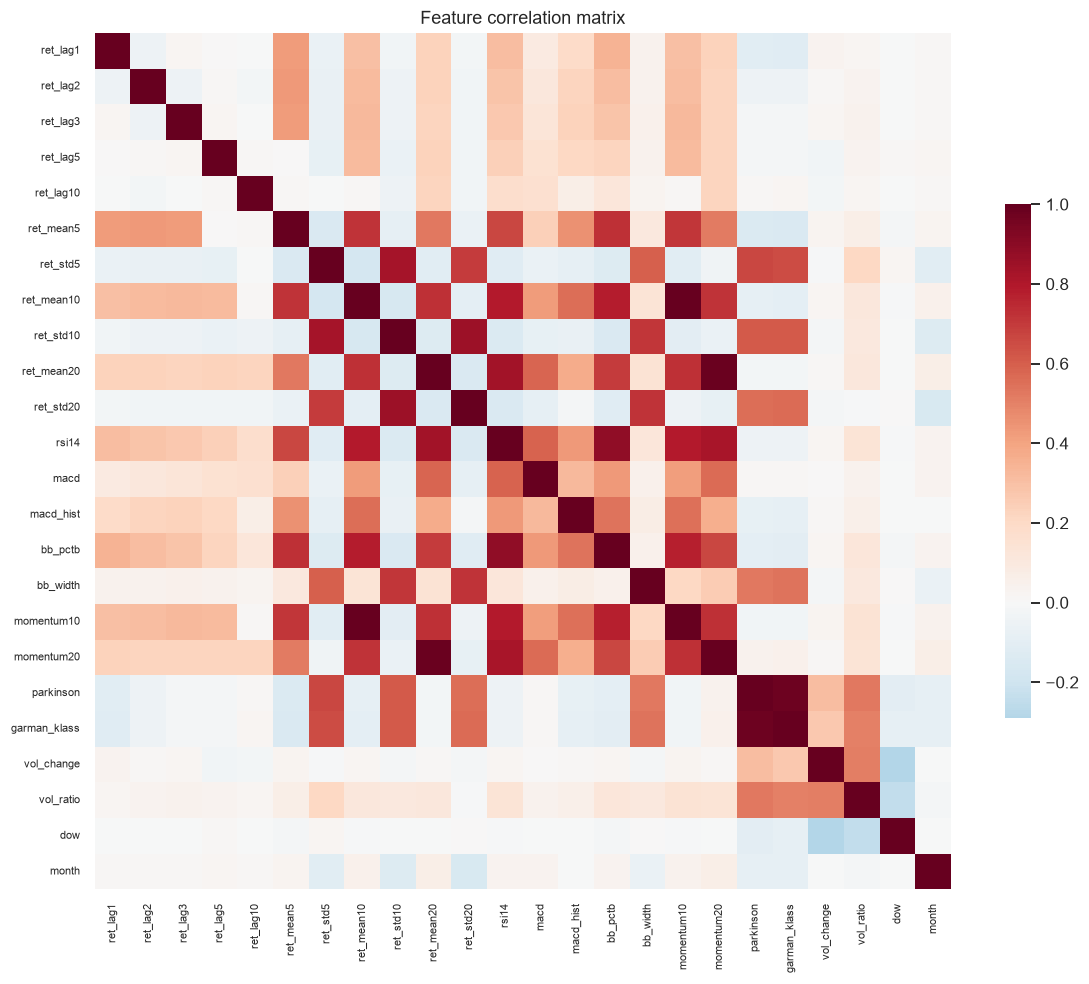

In [5]:
feat_cols=[c for c in f.columns if not c.startswith("target")]
corr_target=f[feat_cols].corrwith(f["target_return"]).abs().sort_values(ascending=False)
corr_target.round(4).to_csv(TAB/"feature_target_corr.csv")
print("Top |correlation| with tomorrow's return (expect all tiny):")
print(corr_target.head(8).round(4))

fig,ax=plt.subplots(figsize=(11,9))
sns.heatmap(f[feat_cols].corr(), cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink":0.6}, xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Feature correlation matrix")
plt.xticks(fontsize=7, rotation=90); plt.yticks(fontsize=7)
fig.tight_layout(); fig.savefig(FIG/"feature_corr_heatmap.png", bbox_inches="tight"); plt.show()

## Takeaways

- Built a broad, **leakage-free** feature set: momentum, oscillators, trend signals, range-based volatility, and volume — plus optional on-chain log-changes.
- The target is a strict **forward shift**, so no feature can see the answer.
- Feature/target correlations are tiny (as the stats predicted) — the honest reality that makes this a hard, interesting problem rather than a trivial one.
- Output saved to `data/processed/btc_features.csv`, ready for the classical ML baselines (06) and the LSTM/GRU benchmark (07).

If you want the on-chain layer live, run `python scripts/fetch_onchain.py` then re-run this notebook — the new features merge in automatically.